#  Assignment No. 6

###  Title: Naive Bayesian Classifier using R
###  Dataset: Pima Indians Diabetes Dataset

# 1. Install & Load Libraries

In [1]:
if (!require(e1071))      install.packages("e1071",      repos="https://cran.r-project.org")
if (!require(caret))      install.packages("caret",      repos="https://cran.r-project.org")
if (!require(ggplot2))    install.packages("ggplot2",    repos="https://cran.r-project.org")
if (!require(mlbench))    install.packages("mlbench",    repos="https://cran.r-project.org")
if (!require(ROCR))       install.packages("ROCR",       repos="https://cran.r-project.org")

library(e1071)
library(caret)
library(ggplot2)
library(mlbench)
library(ROCR)

Loading required package: e1071

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘e1071’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Loading required package: caret

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘caret’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Loading required package: ggplot2

Loading required package: mlbench

Warning message in library(package, lib.loc = lib.loc, charact

# 2. Load & Explore Dataset

In [2]:
data("PimaIndiansDiabetes")
dataset <- PimaIndiansDiabetes

cat("===== Dataset Overview =====\n")
cat("Dimensions:", nrow(dataset), "rows x", ncol(dataset), "columns\n\n")
str(dataset)

cat("\n===== First 6 Rows =====\n")
print(head(dataset))

cat("\n===== Summary Statistics =====\n")
print(summary(dataset))

cat("\n===== Class Distribution =====\n")
print(table(dataset$diabetes))
cat("Proportion:\n")
print(prop.table(table(dataset$diabetes)))

===== Dataset Overview =====
Dimensions: 768 rows x 9 columns

'data.frame':	768 obs. of  9 variables:
 $ pregnant: num  6 1 8 1 0 5 3 10 2 8 ...
 $ glucose : num  148 85 183 89 137 116 78 115 197 125 ...
 $ pressure: num  72 66 64 66 40 74 50 0 70 96 ...
 $ triceps : num  35 29 0 23 35 0 32 0 45 0 ...
 $ insulin : num  0 0 0 94 168 0 88 0 543 0 ...
 $ mass    : num  33.6 26.6 23.3 28.1 43.1 25.6 31 35.3 30.5 0 ...
 $ pedigree: num  0.627 0.351 0.672 0.167 2.288 ...
 $ age     : num  50 31 32 21 33 30 26 29 53 54 ...
 $ diabetes: Factor w/ 2 levels "neg","pos": 2 1 2 1 2 1 2 1 2 2 ...

===== First 6 Rows =====
  pregnant glucose pressure triceps insulin mass pedigree age diabetes
1        6     148       72      35       0 33.6    0.627  50      pos
2        1      85       66      29       0 26.6    0.351  31      neg
3        8     183       64       0       0 23.3    0.672  32      pos
4        1      89       66      23      94 28.1    0.167  21      neg
5        0     137       40

# 3. Handle Missing / Zero Values

In [3]:
# In Pima dataset, 0s in medical fields are biologically impossible → treat as NA
cols_with_zeros <- c("glucose", "pressure", "triceps", "insulin", "mass")
dataset[cols_with_zeros][dataset[cols_with_zeros] == 0] <- NA

cat("\n===== Missing Values per Column =====\n")
print(colSums(is.na(dataset)))

# Impute with column medians
for (col in cols_with_zeros) {
  dataset[[col]][is.na(dataset[[col]])] <- median(dataset[[col]], na.rm = TRUE)
}
cat("Missing values imputed with column medians.\n")


===== Missing Values per Column =====
pregnant  glucose pressure  triceps  insulin     mass pedigree      age 
       0        5       35      227      374       11        0        0 
diabetes 
       0 
Missing values imputed with column medians.


# 4. Exploratory Data Analysis

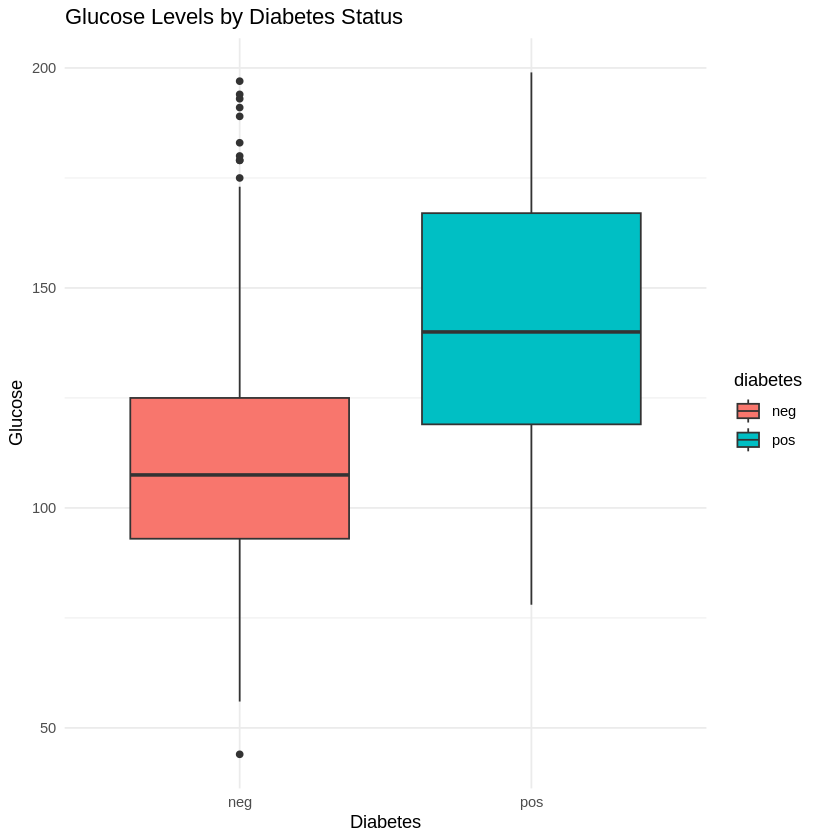

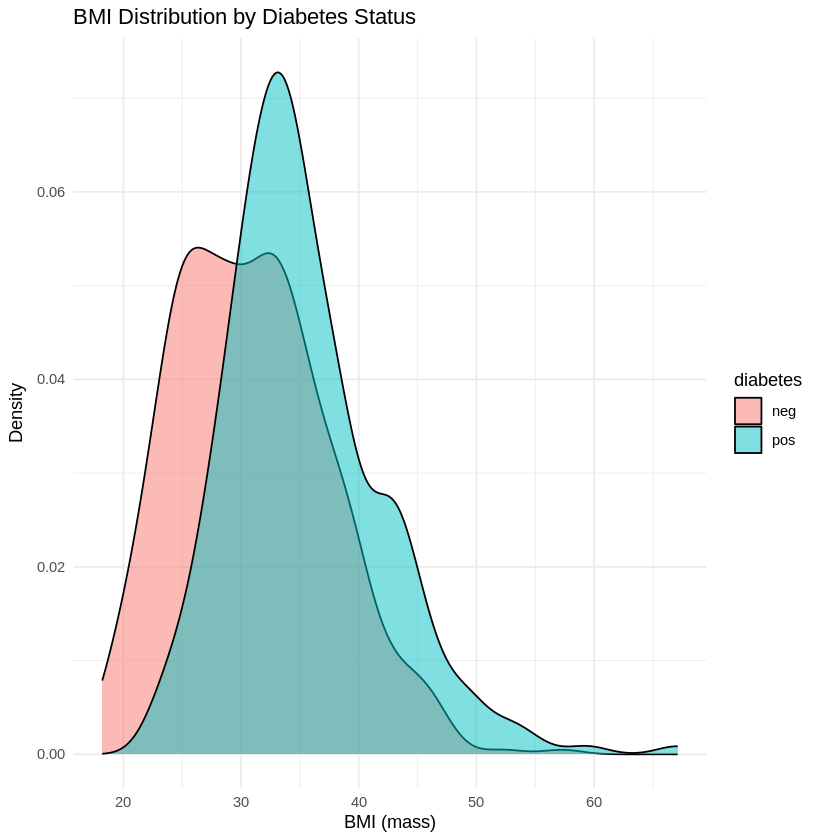

In [4]:
# Boxplot: Glucose by Diabetes class
ggplot(dataset, aes(x = diabetes, y = glucose, fill = diabetes)) +
  geom_boxplot() +
  labs(title = "Glucose Levels by Diabetes Status",
       x = "Diabetes", y = "Glucose") +
  theme_minimal()

# Density plot: BMI by class
ggplot(dataset, aes(x = mass, fill = diabetes)) +
  geom_density(alpha = 0.5) +
  labs(title = "BMI Distribution by Diabetes Status",
       x = "BMI (mass)", y = "Density") +
  theme_minimal()

# 5. Train / Test Split

In [5]:
set.seed(42)
train_index <- createDataPartition(dataset$diabetes, p = 0.80, list = FALSE)
train_data  <- dataset[ train_index, ]
test_data   <- dataset[-train_index, ]

cat("\n===== Split Sizes =====\n")
cat("Training set:", nrow(train_data), "rows\n")
cat("Test set    :", nrow(test_data),  "rows\n")


===== Split Sizes =====
Training set: 615 rows
Test set    : 153 rows


# 6. Train Naive Bayes Classifier

In [6]:
nb_model <- naiveBayes(diabetes ~ ., data = train_data)

cat("\n===== Naive Bayes Model =====\n")
print(nb_model)


===== Naive Bayes Model =====

Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
      neg       pos 
0.6504065 0.3495935 

Conditional probabilities:
     pregnant
Y         [,1]     [,2]
  neg 3.277500 3.046094
  pos 5.023256 3.857802

     glucose
Y         [,1]     [,2]
  neg 110.1975 24.54975
  pos 141.8698 29.35589

     pressure
Y         [,1]     [,2]
  neg 71.00750 12.08792
  pos 75.54419 12.26029

     triceps
Y         [,1]     [,2]
  neg 27.69750 8.392083
  pos 31.52558 7.618721

     insulin
Y         [,1]     [,2]
  neg 127.8500 73.52712
  pos 162.4837 96.89506

     mass
Y         [,1]     [,2]
  neg 31.08325 6.425384
  pos 35.61721 6.720976

     pedigree
Y          [,1]      [,2]
  neg 0.4276150 0.3011366
  pos 0.5600977 0.3732657

     age
Y         [,1]     [,2]
  neg 31.37250 12.13123
  pos 36.65116 10.49362



# 7. Make Predictions

In [7]:
predictions      <- predict(nb_model, test_data)
predictions_prob <- predict(nb_model, test_data, type = "raw")

cat("\n===== Predicted vs Actual (first 20 rows) =====\n")
comparison_df <- data.frame(
  Actual    = test_data$diabetes,
  Predicted = predictions
)
print(head(comparison_df, 20))


===== Predicted vs Actual (first 20 rows) =====
   Actual Predicted
1     pos       pos
2     pos       neg
3     pos       pos
4     pos       pos
5     neg       neg
6     pos       neg
7     neg       pos
8     neg       neg
9     neg       neg
10    pos       pos
11    neg       pos
12    neg       neg
13    neg       neg
14    neg       neg
15    neg       pos
16    pos       neg
17    neg       neg
18    neg       neg
19    neg       neg
20    neg       neg


# 8. Model Evaluation

In [8]:
cat("\n===== Confusion Matrix =====\n")
cm <- confusionMatrix(predictions, test_data$diabetes, positive = "pos")
print(cm)

cat("\n===== Key Metrics =====\n")
cat("Accuracy  :", round(cm$overall["Accuracy"],  4), "\n")
cat("Kappa     :", round(cm$overall["Kappa"],     4), "\n")
cat("Sensitivity (Recall) :", round(cm$byClass["Sensitivity"], 4), "\n")
cat("Specificity          :", round(cm$byClass["Specificity"],  4), "\n")
cat("Precision            :", round(cm$byClass["Pos Pred Value"], 4), "\n")
cat("F1 Score             :", round(cm$byClass["F1"], 4), "\n")


===== Confusion Matrix =====
Confusion Matrix and Statistics

          Reference
Prediction neg pos
       neg  82  21
       pos  18  32
                                         
               Accuracy : 0.7451         
                 95% CI : (0.6684, 0.812)
    No Information Rate : 0.6536         
    P-Value [Acc > NIR] : 0.009661       
                                         
                  Kappa : 0.4295         
                                         
 Mcnemar's Test P-Value : 0.748774       
                                         
            Sensitivity : 0.6038         
            Specificity : 0.8200         
         Pos Pred Value : 0.6400         
         Neg Pred Value : 0.7961         
             Prevalence : 0.3464         
         Detection Rate : 0.2092         
   Detection Prevalence : 0.3268         
      Balanced Accuracy : 0.7119         
                                         
       'Positive' Class : pos            
                    

# 9. ROC Curve


AUC: 0.7819 


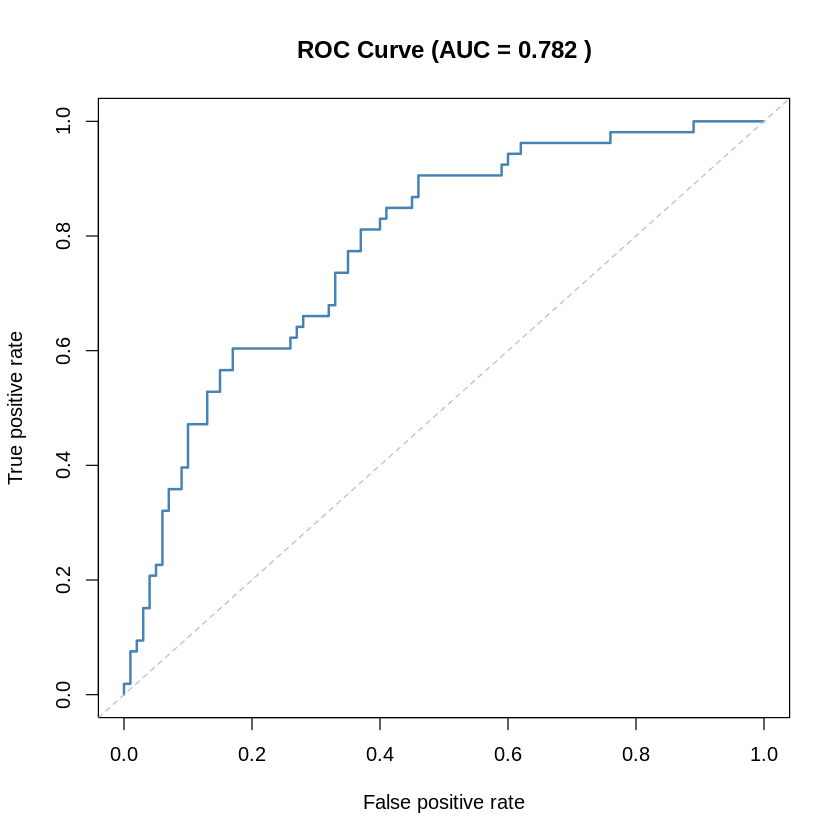

In [9]:
pred_obj <- prediction(predictions_prob[, "pos"], test_data$diabetes)
perf_roc  <- performance(pred_obj, "tpr", "fpr")
auc_val   <- performance(pred_obj, "auc")@y.values[[1]]

plot(perf_roc,
     main = paste("ROC Curve (AUC =", round(auc_val, 3), ")"),
     col  = "steelblue", lwd = 2)
abline(a = 0, b = 1, lty = 2, col = "gray")

cat("\nAUC:", round(auc_val, 4), "\n")

# 10. Cross-Validation

In [10]:
cat("\n===== 10-Fold Cross-Validation =====\n")
# Install and load the 'naivebayes' package if not already installed/loaded
if (!require(naivebayes)) install.packages("naivebayes", repos="https://cran.r-project.org")
library(naivebayes)

ctrl <- trainControl(method = "cv", number = 10)
cv_model <- train(diabetes ~ .,
                  data      = dataset,
                  method    = "naive_bayes",
                  trControl = ctrl)
print(cv_model)


===== 10-Fold Cross-Validation =====


Loading required package: naivebayes

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘naivebayes’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

naivebayes 1.0.0 loaded

For more information please visit: 

https://majkamichal.github.io/naivebayes/



Naive Bayes 

768 samples
  8 predictor
  2 classes: 'neg', 'pos' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 691, 692, 691, 691, 691, 692, ... 
Resampling results across tuning parameters:

  usekernel  Accuracy   Kappa    
  FALSE      0.7473855  0.4346157
   TRUE      0.7551606  0.4572674

Tuning parameter 'laplace' was held constant at a value of 0
Tuning
 parameter 'adjust' was held constant at a value of 1
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were laplace = 0, usekernel = TRUE
 and adjust = 1.
